# <span style="color:blue">Project Code of SKYHACK Hackathon

# Part-I EDA

### Importing Libraries & Datasets

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Style of Seaborn
sns.set_style("whitegrid")
sns.set_context("talk")
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Loading all Datasets
airports = pd.read_csv("AirportsData.csv")
bags = pd.read_csv("BagLevelData.csv")
flights = pd.read_csv("FlightLevelData.csv")
pnr = pd.read_csv("PNRFlightLevelData.csv")
remarks = pd.read_csv("PNRRemarkLevelData.csv")

### Preprocessing

In [58]:
flights['scheduled_departure_datetime_local'] = pd.to_datetime(flights['scheduled_departure_datetime_local'])
flights['actual_departure_datetime_local'] = pd.to_datetime(flights['actual_departure_datetime_local'])
bags['bag_tag_issue_date'] = pd.to_datetime(bags['bag_tag_issue_date'])
pnr['pnr_creation_date'] = pd.to_datetime(pnr['pnr_creation_date'])
remarks['pnr_creation_date'] = pd.to_datetime(remarks['pnr_creation_date'])

# Bag counts
bag_counts = bags.groupby(['company_id','flight_number','scheduled_departure_date_local','bag_type']).size().unstack(fill_value=0).reset_index()
bag_counts['total_bags'] = bag_counts.sum(axis=1, numeric_only=True)
bag_counts['transfer_ratio'] = bag_counts.get('Transfer', 0) / bag_counts['total_bags']

# Passenger load
passenger_counts = pnr.groupby(['company_id','flight_number','scheduled_departure_date_local'])['total_pax'].sum().reset_index()

# Special service requests
special_requests = remarks.groupby(['flight_number','pnr_creation_date']).size().reset_index(name='special_service_count')
pnr_flight = pnr[['company_id','flight_number','scheduled_departure_date_local','record_locator']].drop_duplicates()
special_requests = special_requests.merge(pnr_flight, left_on=['flight_number'], right_on=['flight_number'], how='left')
special_requests = special_requests.groupby(['company_id','flight_number','scheduled_departure_date_local'])['special_service_count'].sum().reset_index()

# Merge all into flights
flights_eda = flights.merge(bag_counts[['company_id','flight_number','scheduled_departure_date_local','transfer_ratio']],
                            on=['company_id','flight_number','scheduled_departure_date_local'], how='left')
flights_eda = flights_eda.merge(passenger_counts, on=['company_id','flight_number','scheduled_departure_date_local'], how='left')
flights_eda = flights_eda.merge(special_requests, on=['company_id','flight_number','scheduled_departure_date_local'], how='left')

# Computing delays
flights_eda['departure_delay_min'] = (flights_eda['actual_departure_datetime_local'] - flights_eda['scheduled_departure_datetime_local']).dt.total_seconds() / 60


### 1️⃣ What is the average delay and what percentage of flights depart later than scheduled?

Average Departure Delay: 21.18 min
Percentage of Flights Departing Late: 49.61%


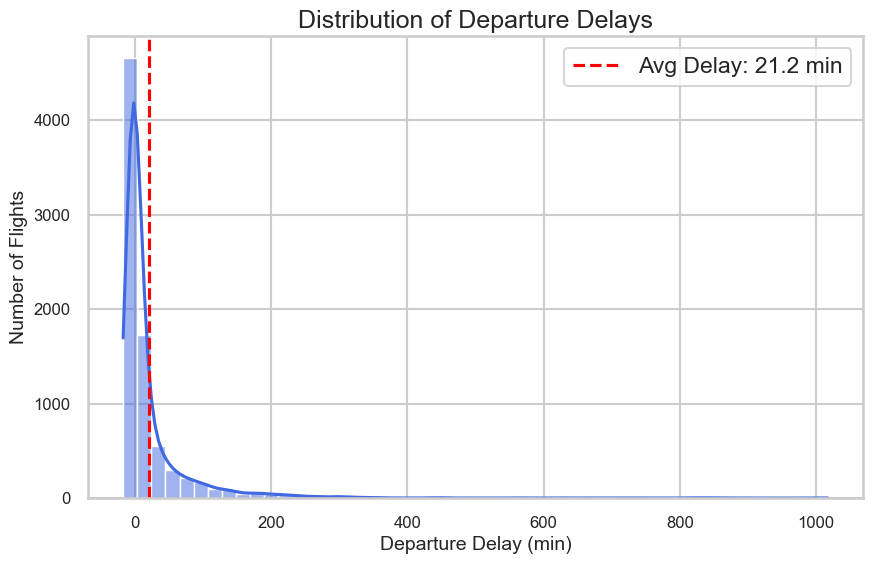

In [59]:
avg_delay = flights_eda['departure_delay_min'].mean()
pct_late = (flights_eda['departure_delay_min'] > 0).mean() * 100
print(f"Average Departure Delay: {avg_delay:.2f} min")
print(f"Percentage of Flights Departing Late: {pct_late:.2f}%")

plt.figure()
sns.histplot(flights_eda['departure_delay_min'], bins=50, kde=True, color='royalblue')
plt.axvline(avg_delay, color='red', linestyle='--', label=f'Avg Delay: {avg_delay:.1f} min')
plt.xlabel("Departure Delay (min)")
plt.ylabel("Number of Flights")
plt.title("Distribution of Departure Delays")
plt.legend()
plt.show()

### 2️⃣ How many flights have scheduled ground time close to or below the minimum turn mins?

Flights with scheduled ground <= minimum turn: 652


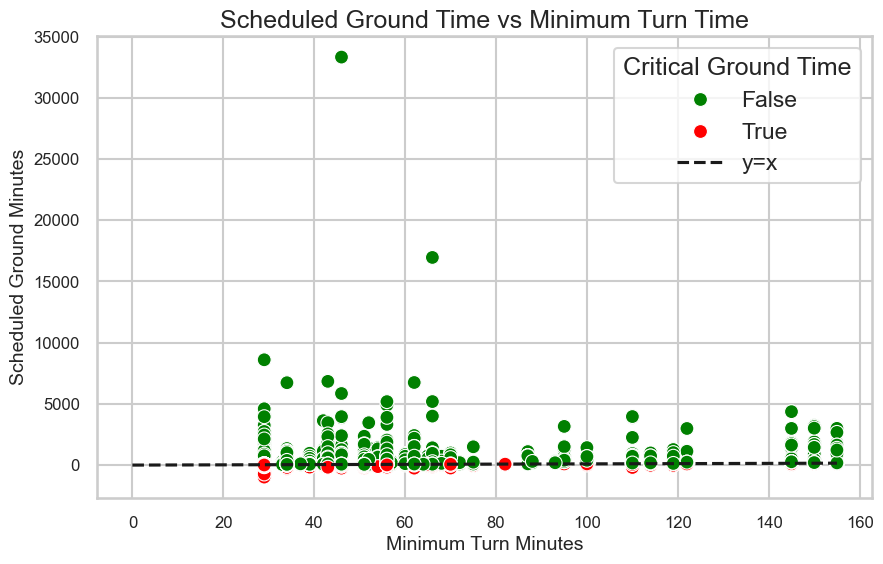

In [60]:
ground_time_critical = flights_eda[flights_eda['scheduled_ground_time_minutes'] <= flights_eda['minimum_turn_minutes']]
print(f"Flights with scheduled ground <= minimum turn: {len(ground_time_critical)}")

plt.figure()
sns.scatterplot(
    data=flights_eda,
    x='minimum_turn_minutes',
    y='scheduled_ground_time_minutes',
    hue=(flights_eda['scheduled_ground_time_minutes'] <= flights_eda['minimum_turn_minutes']),
    palette={True:'red', False:'green'},
    s=100
)
plt.plot([0, flights_eda['minimum_turn_minutes'].max()], [0, flights_eda['minimum_turn_minutes'].max()], 'k--', label='y=x')
plt.xlabel("Minimum Turn Minutes")
plt.ylabel("Scheduled Ground Minutes")
plt.title("Scheduled Ground Time vs Minimum Turn Time")
plt.legend(title="Critical Ground Time")
plt.show()

### 3️⃣ What is the average ratio of transfer bags vs. checked bags across flights?

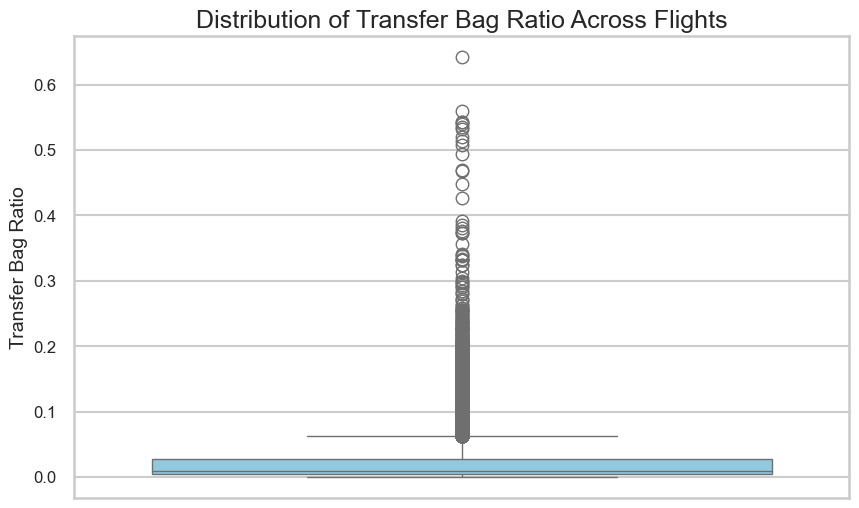

In [61]:
plt.figure()
sns.boxplot(y=flights_eda['transfer_ratio'], color='skyblue')
plt.ylabel("Transfer Bag Ratio")
plt.title("Distribution of Transfer Bag Ratio Across Flights")
plt.show()

### 4️⃣ How do passenger loads compare across flights, and do higher loads correlate with operational difficulty?

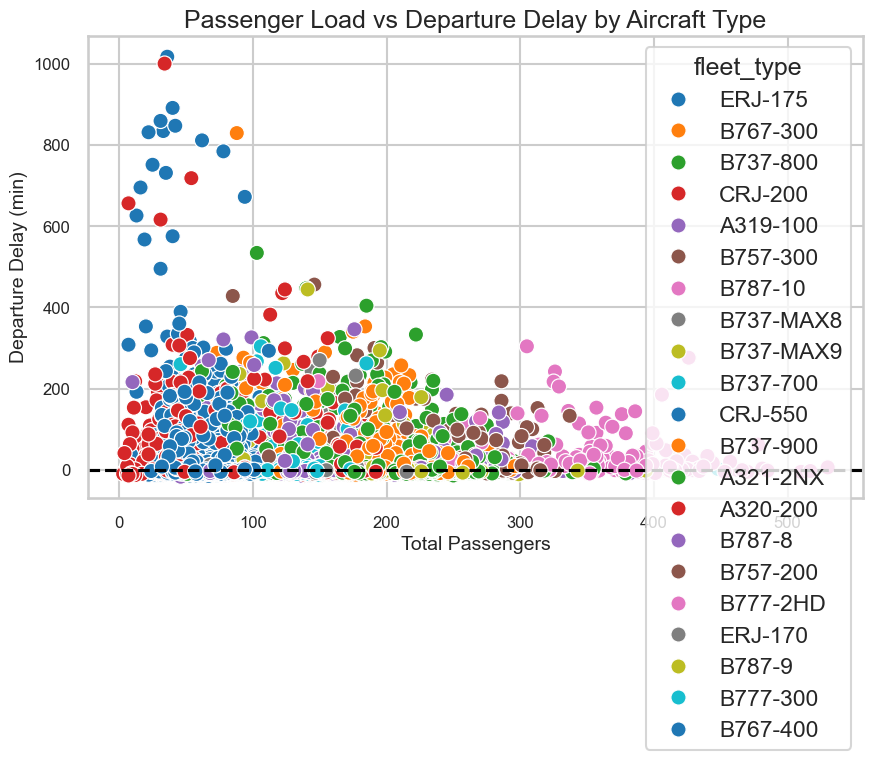

Correlation between passenger load and delay: -0.02


In [62]:
plt.figure()
sns.scatterplot(data=flights_eda, x='total_pax', y='departure_delay_min', hue='fleet_type', palette='tab10', s=120)
plt.xlabel("Total Passengers")
plt.ylabel("Departure Delay (min)")
plt.title("Passenger Load vs Departure Delay by Aircraft Type")
plt.axhline(0, color='black', linestyle='--')
plt.show()

corr_load_delay = flights_eda[['total_pax','departure_delay_min']].corr().iloc[0,1]
print(f"Correlation between passenger load and delay: {corr_load_delay:.2f}")

### 5️⃣ Are high special service requests flights also high-delay after controlling for load?

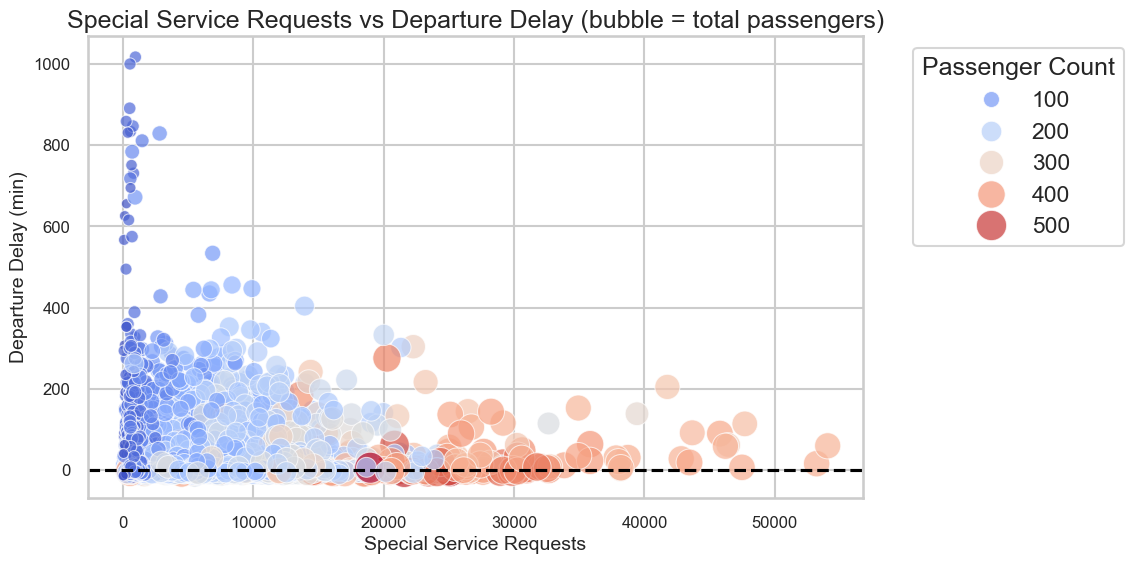

In [63]:
plt.figure()
sns.scatterplot(
    data=flights_eda,
    x='special_service_count',
    y='departure_delay_min',
    size='total_pax',
    hue='total_pax',
    palette='coolwarm',
    sizes=(50, 500),
    alpha=0.7
)
plt.xlabel("Special Service Requests")
plt.ylabel("Departure Delay (min)")
plt.title("Special Service Requests vs Departure Delay (bubble = total passengers)")
plt.axhline(0, color='black', linestyle='--')
plt.legend(title='Passenger Count', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


# Part - II Flight Difficulty Score

### Importing Libraries

In [64]:
from sklearn.preprocessing import MinMaxScaler

### Flight Difficulty Score Development

In [65]:
flights['scheduled_departure_date_local'] = pd.to_datetime(flights['scheduled_departure_date_local'])
flights['departure_delay_minutes'] = (pd.to_datetime(flights['actual_departure_datetime_local']) - pd.to_datetime(flights['scheduled_departure_datetime_local'])).dt.total_seconds()/60
flights['departure_delay_minutes'] = flights['departure_delay_minutes'].fillna(0).clip(lower=0)

bags = bags.apply(pd.to_numeric, errors='coerce').fillna(0)
total_bags = bags.sum(axis=1).replace(0, np.nan)
bags['transfer_ratio'] = bags.get('Transfer',0)/total_bags
bags['transfer_ratio'] = bags['transfer_ratio'].fillna(0)

merge_keys = ['company_id','flight_number','scheduled_departure_date_local']
for key in merge_keys:
    flights[key] = flights[key].astype(str)
    bags[key] = bags[key].astype(str)
pnr['scheduled_departure_date_local'] = pd.to_datetime(pnr['scheduled_departure_date_local'])
for key in ['company_id','flight_number','scheduled_departure_date_local']:
    pnr[key] = pnr[key].astype(str)
remarks['flight_number'] = remarks['flight_number'].astype(str)

merged = flights.merge(bags, on=merge_keys, how='left')
pnr_summary = pnr.groupby(merge_keys)['total_pax'].sum().reset_index()
pnr_summary.rename(columns={'total_pax':'total_pax'}, inplace=True)
merged = merged.merge(pnr_summary, on=merge_keys, how='left')

ssr_summary = remarks.groupby('flight_number').size().reset_index(name='ssr_count')
merged = merged.merge(ssr_summary, on='flight_number', how='left')
merged = merged.fillna({'total_pax':0,'transfer_ratio':0,'ssr_count':0})

merged['load_factor'] = merged['total_pax']/merged['total_pax'].max()
merged['delay_factor'] = merged['departure_delay_minutes']/(merged['scheduled_ground_time_minutes']+1)
merged['bag_factor'] = merged['transfer_ratio']
merged['ssr_factor'] = merged['ssr_count']/merged['ssr_count'].max()
merged['difficulty_score_raw'] = 0.5*merged['delay_factor'] + 0.25*merged['load_factor'] + 0.15*merged['bag_factor'] + 0.1*merged['ssr_factor']
# Replace inf or -inf with NaN
merged['difficulty_score_raw'].replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN with 0
merged['difficulty_score_raw'] = merged['difficulty_score_raw'].fillna(0)

# Clip extremely large values if any
merged['difficulty_score_raw'] = merged['difficulty_score_raw'].clip(upper=1000)

# Now safe to MinMax scale
merged['difficulty_score'] = merged.groupby('scheduled_departure_date_local')['difficulty_score_raw']\
    .transform(lambda x: MinMaxScaler().fit_transform(x.values.reshape(-1,1)).flatten())
merged['daily_rank'] = merged.groupby('scheduled_departure_date_local')['difficulty_score'].rank(ascending=False, method='first')

def classify(rank,total):
    pct = rank/total
    if pct<=0.33:
        return 'Difficult'
    elif pct<=0.66:
        return 'Medium'
    else:
        return 'Easy'

merged['total_daily_flights'] = merged.groupby('scheduled_departure_date_local')['flight_number'].transform('count')
merged['difficulty_class'] = merged.apply(lambda row: classify(row['daily_rank'],row['total_daily_flights']), axis=1)

output = merged[['company_id', 'flight_number', 'scheduled_departure_date_local', 'scheduled_departure_station_code_x', 'scheduled_arrival_station_code_x', 'scheduled_departure_datetime_local', 'scheduled_arrival_datetime_local', 'actual_departure_datetime_local', 'actual_arrival_datetime_local', 'total_seats', 'fleet_type', 'carrier', 'scheduled_ground_time_minutes', 'actual_ground_time_minutes', 'minimum_turn_minutes', 'departure_delay_minutes', 'scheduled_departure_station_code_y', 'scheduled_arrival_station_code_y', 'bag_tag_unique_number', 'bag_tag_issue_date', 'bag_type', 'transfer_ratio', 'total_pax', 'ssr_count', 'load_factor', 'delay_factor', 'bag_factor', 'ssr_factor', 'difficulty_score_raw', 'difficulty_score', 'daily_rank', 'total_daily_flights', 'difficulty_class']].sort_values(['scheduled_departure_date_local','daily_rank'])
output.to_csv("test_inittowinit.csv", index=False)


# Part III - Post Analysis Insights

### Ranking Destinations by difficulty

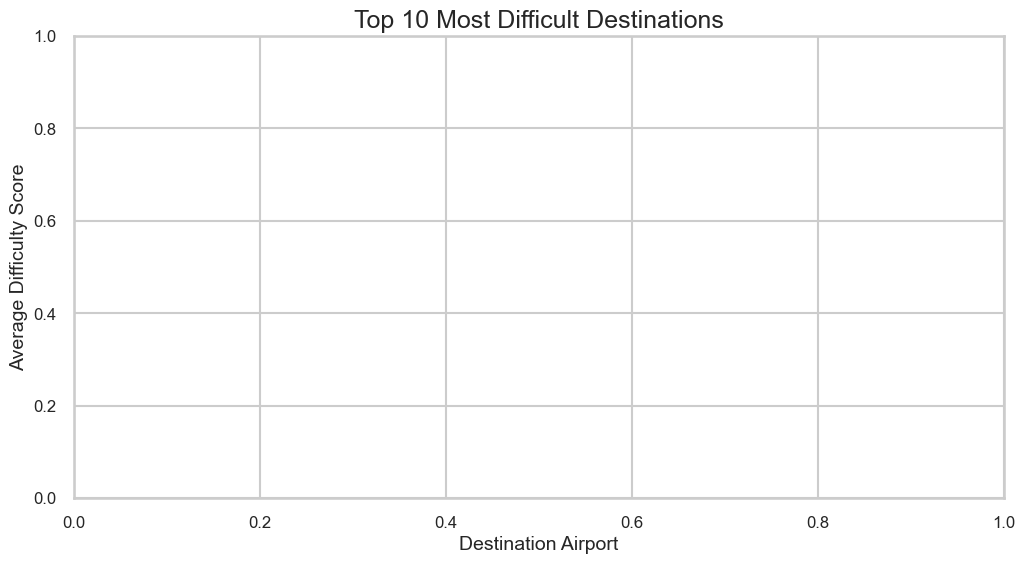

In [66]:
dest_summary = merged.groupby('scheduled_arrival_station_code_y')['difficulty_score'].mean().sort_values(ascending=False).reset_index()
top_destinations = dest_summary.head(10)

# Visualization
plt.figure(figsize=(12,6))
sns.barplot(data=top_destinations, x='scheduled_arrival_station_code_y', y='difficulty_score', palette='Reds_r')
plt.title('Top 10 Most Difficult Destinations')
plt.ylabel('Average Difficulty Score')
plt.xlabel('Destination Airport')
plt.show()


### Correlation/Interdependence of featrures with difficulty

Correlation of features with difficulty score:
difficulty_score           1.000000
departure_delay_minutes    0.102354
load_factor                0.030894
ssr_count                  0.010149
transfer_ratio                  NaN
Name: difficulty_score, dtype: float64


/var/folders/8w/kbd0zl4s7hj_c0fpnty0g3480000gn/T/ipykernel_84448/3962008501.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_df.index[1:], y=corr_df.values[1:], palette='Blues')


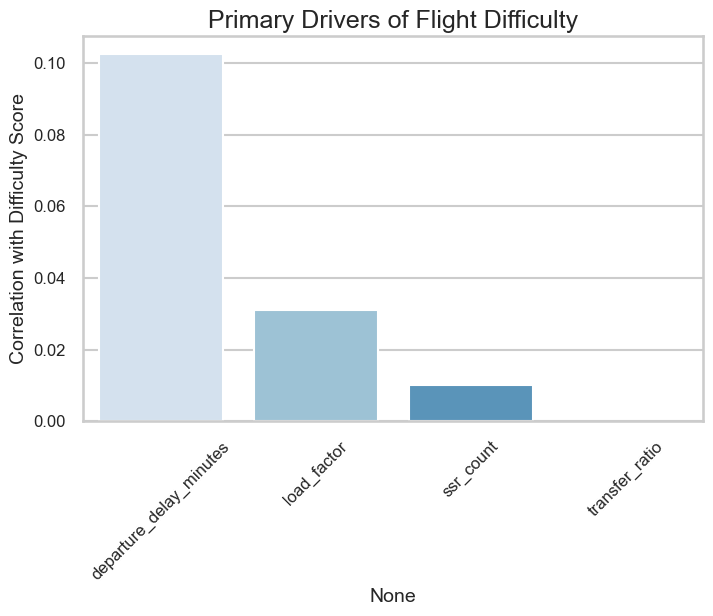

In [67]:
feature_cols = ['departure_delay_minutes','load_factor','transfer_ratio','ssr_count']
corr_df = merged[feature_cols + ['difficulty_score']].corr()['difficulty_score'].sort_values(ascending=False)
print("Correlation of features with difficulty score:")
print(corr_df)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(x=corr_df.index[1:], y=corr_df.values[1:], palette='Blues')
plt.title('Primary Drivers of Flight Difficulty')
plt.ylabel('Correlation with Difficulty Score')
plt.xticks(rotation=45)
plt.show()

### Flight Identification by Drivers/Factors

In [68]:
high_delay = merged[merged['departure_delay_minutes'] > merged['departure_delay_minutes'].quantile(0.75)]
high_load = merged[merged['load_factor'] > merged['load_factor'].quantile(0.75)]
high_transfer = merged[merged['transfer_ratio'] > merged['transfer_ratio'].quantile(0.75)]
high_ssr = merged[merged['ssr_count'] > merged['ssr_count'].quantile(0.75)]

### Summary

In [69]:
driver_summary = pd.DataFrame({
    'Driver':['High Delay','High Load','High Transfer Bags','High Special Requests'],
    'Flights Count':[len(high_delay), len(high_load), len(high_transfer), len(high_ssr)]
})
print(driver_summary)

                  Driver  Flights Count
0             High Delay           1996
1              High Load           1996
2     High Transfer Bags              0
3  High Special Requests           2010
